# Spectral MAE inspection

Load `checkpoint.pt` from this folder, pick a `hypercube.npy`, run **SpectralMAE** from `train.py`, denormalize to reflectance, and plot RGB composites plus spectra.

**Edit** `HYPERCUBE_PATH` below if your chip lives elsewhere.

**Masking:** use `USE_FIXED_MASK` to force a simple deterministic mask, or set `SEED` with `USE_FIXED_MASK = False` for a reproducible random mask (same as training uses `P_MASK`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

_NB_DIR = Path.cwd().resolve()
if str(_NB_DIR) not in sys.path:
    sys.path.insert(0, str(_NB_DIR))

import train as T
import utils

CHECKPOINT = _NB_DIR / "checkpoint.pt"
# Example chip — change to any valid hypercube.npy matching training shape (H,W,C)
HYPERCUBE_PATH = Path.home() / "emit_data" / "20220810T064957_ch4" / "negative_chip_0" / "hypercube.npy"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [2]:
if not CHECKPOINT.is_file():
    raise FileNotFoundError(CHECKPOINT)

ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
meta = ckpt["meta"]
H, W, C = int(meta["H"]), int(meta["W"]), int(meta["C"])

model = T.SpectralMAE(
    C, H, W, T.PATCH_SIZE, T.EMBED_DIM, T.ENC_DEPTH, T.DEC_DEPTH, T.NUM_HEADS
).to(DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()

wl = ckpt["wavelengths"].to(DEVICE).float()
band_mean = ckpt["band_mean"].to(DEVICE).view(C, 1, 1)
band_std = ckpt["band_std"].to(DEVICE).view(C, 1, 1)
H, W, C

(256, 256, 285)

In [3]:
if not HYPERCUBE_PATH.is_file():
    raise FileNotFoundError(HYPERCUBE_PATH)

raw = np.load(HYPERCUBE_PATH)
if raw.shape != (H, W, C):
    raise ValueError(f"Cube shape {raw.shape} does not match checkpoint meta {(H, W, C)}")

x = utils.tensor_hypercube_to_model_input(raw, ckpt["band_mean"], ckpt["band_std"], DEVICE)
x.shape

torch.Size([1, 285, 256, 256])

### Inference

`mask_idx` selects which spectral bands are masked and reconstructed. Training draws a random subset each step; here you can mirror that with a fixed **seed**, or mask the first `nm` bands for a predictable demo.

In [4]:
USE_FIXED_MASK = False
SEED = 0

nm = max(1, min(C - 1, int(round(T.P_MASK * C))))
if USE_FIXED_MASK:
    mask_idx = torch.arange(nm, device=DEVICE)
else:
    torch.manual_seed(SEED)
    mask_idx = torch.randperm(C, device=DEVICE)[:nm].sort()[0]

with torch.inference_mode():
    pred, midx = model(x, wl, mask_idx)

assert torch.equal(mask_idx, midx)
pred.shape, mask_idx.numel()

(torch.Size([1, 285, 256, 256]), 228)

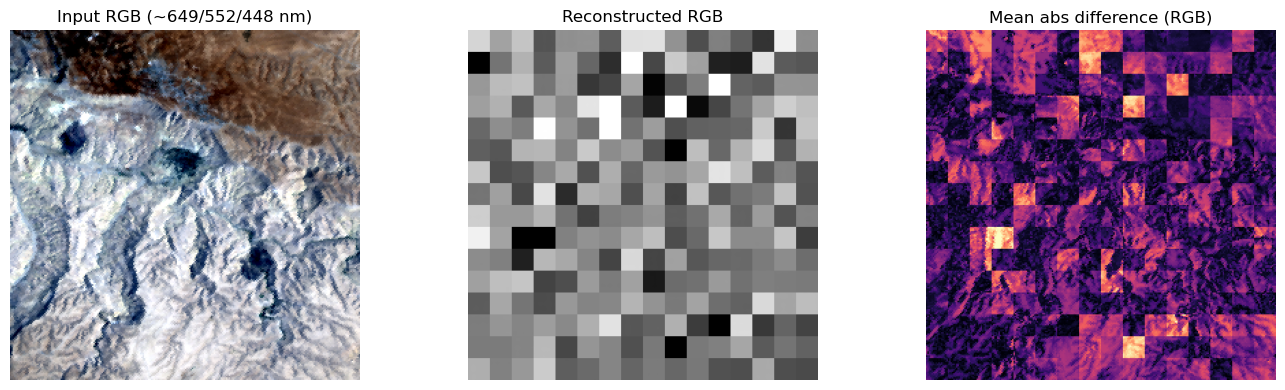

In [5]:
inp_phys = utils.denormalize_nchw(x, band_mean, band_std).squeeze(0)
pred_phys = utils.denormalize_nchw(pred, band_mean, band_std).squeeze(0)

inp_np = inp_phys.cpu().numpy().transpose(1, 2, 0)
pred_np = pred_phys.cpu().numpy().transpose(1, 2, 0)
wl_cpu = ckpt["wavelengths"].cpu().numpy()

r_i, g_i, b_i = utils.nearest_band_indices(wl_cpu)
rgb_in = inp_np[..., [r_i, g_i, b_i]]
rgb_pr = pred_np[..., [r_i, g_i, b_i]]
rgb_in_s = utils.rgb_percentile_stretch(rgb_in)
rgb_pr_s = utils.rgb_percentile_stretch(rgb_pr)
rgb_diff = np.mean(np.abs(rgb_in_s - rgb_pr_s), axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(rgb_in_s)
axes[0].set_title(f"Input RGB (~{wl_cpu[r_i]:.0f}/{wl_cpu[g_i]:.0f}/{wl_cpu[b_i]:.0f} nm)")
axes[1].imshow(rgb_pr_s)
axes[1].set_title("Reconstructed RGB")
axes[2].imshow(rgb_diff, cmap="magma")
axes[2].set_title("Mean abs difference (RGB)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

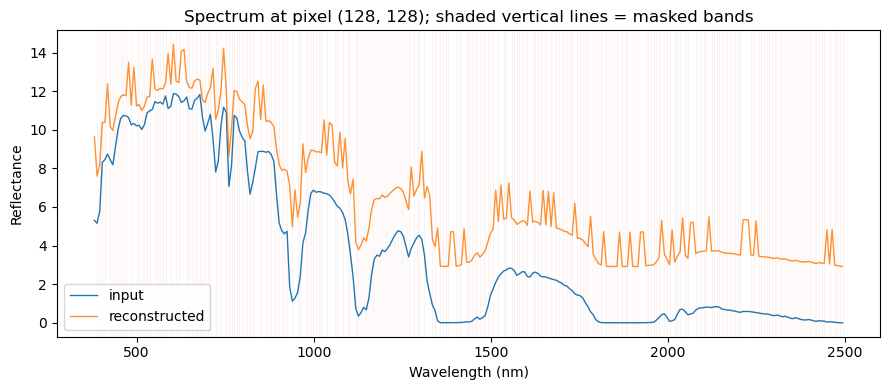

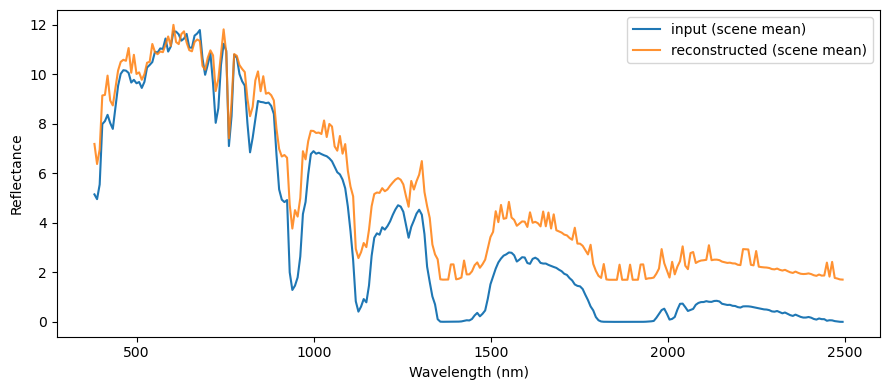

In [6]:
py, px = H // 2, W // 2

fig2, ax = plt.subplots(figsize=(9, 4))
ax.plot(wl_cpu, inp_np[py, px, :], label="input", linewidth=1.0)
ax.plot(wl_cpu, pred_np[py, px, :], label="reconstructed", linewidth=1.0, alpha=0.85)
for j in mask_idx.cpu().numpy():
    ax.axvline(float(wl_cpu[j]), color="tab:red", alpha=0.06, linewidth=0.8)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.set_title(f"Spectrum at pixel ({py}, {px}); shaded vertical lines = masked bands")
ax.legend()
plt.tight_layout()
plt.show()

fig3, ax = plt.subplots(figsize=(9, 4))
ax.plot(wl_cpu, inp_np.reshape(-1, C).mean(axis=0), label="input (scene mean)")
ax.plot(wl_cpu, pred_np.reshape(-1, C).mean(axis=0), label="reconstructed (scene mean)", alpha=0.85)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.legend()
plt.tight_layout()
plt.show()